In [144]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [145]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda:None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data + other.data,(self,other),'+')

        def _backward():
            self.grad += 1.0 * out.grad  #use += instead of =
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __truediv__(self, other): # self / other
        return self * other **-1
    
    def __neg__(self): # -self
        return self*-1
    
    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __pow__(self, other):
        assert isinstance(other,(int,float)),"only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad

        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad 

        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)   
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        

    

### Dunder methods & internal naming conventions

**Dunder methods** (`__add__`, `__mul__`, `__pow__`, `__truediv__`, `__neg__`, `__sub__`, `__radd__`, `__rmul__`, `__repr__`, ...) are *operator overloads* - Python calls them automatically when you use the corresponding syntax:

| Syntax | Method called |
|---|---|
| `a + b` | `a.__add__(b)` |
| `b + a` (when `b` has no usable `__add__`) | `a.__radd__(b)` |
| `a * b` | `a.__mul__(b)` |
| `a ** n` | `a.__pow__(n)` |
| `a / b` | `a.__truediv__(b)` |
| `-a` | `a.__neg__()` |
| `a - b` | `a.__sub__(b)` |
| `print(a)` | `a.__repr__()` |

Most of the "extra" operators (`__sub__`, `__neg__`, `__truediv__`, `__radd__`, `__rmul__`) are implemented *in terms of* `__add__`, `__mul__`, and `__pow__` - so those three (plus `tanh`/`exp`) are the only places that need a real `_backward` implementation.

**Single-underscore attributes** (`_prev`, `_op`, `_backward`, and the `_children` constructor argument) follow Python's "internal use" convention - not enforced by the language, but signaling "this is autograd/visualization bookkeeping, not something you read or set directly":

- `_prev`: the set of `Value`s this node was created from (used to build the graph)
- `_op`: the operator/function that produced this node (used for `draw_dot` labels)
- `_backward`: the local-gradient function for this node, set up at creation time and invoked during `backward()`

### Why `_backward` uses `+=` instead of `=`

**Core reason: the multivariable chain rule.**

If a `Value` is used **more than once** in the computation graph (e.g. `b = a + a`,
or the same weight is shared by multiple neurons), then the gradient of the final
output `L` with respect to it equals the **sum of contributions from every path**:

$$\frac{\partial L}{\partial a} = \sum_{i} \frac{\partial L}{\partial \text{out}_i} \cdot \frac{\partial \text{out}_i}{\partial a}$$

- With `self.grad = ...`, each time `_backward()` is called along a different path,
  it **overwrites** the previous result, so `a.grad` ends up holding only the
  contribution from the *last* path - the others are lost.
- With `self.grad += ...`, each path's contribution is **accumulated**, so the final
  value is the correct total gradient.

Simple example: `b = a + a`, so `db/da = 1 + 1 = 2`.
- First `_backward()` call: `a.grad = 1.0 * b.grad` (from the first `a`)
- Second `_backward()` call: with `=`, this becomes `a.grad = 1.0 * b.grad` again
  (overwritten, wrong - off by a factor of 2); with `+=`, it becomes
  `a.grad += 1.0 * b.grad`, and the two contributions sum to `2 * b.grad`, which is correct.

**Note (the matching requirement):** because gradients accumulate, `.grad` must be
reset to `0` before each `backward()` call (or initialized to `0` for new `Value`s),
otherwise gradients from a previous backward pass will pile on top of the current
ones and blow up.

### Topological sort in `backward()`

`backward()` needs to call every node's `_backward()` in the right order: a node's `.grad` must be **fully accumulated** before its own `_backward()` runs, since `_backward()` reads `out.grad` to compute the gradients of its inputs.

`build_topo` does a DFS post-order traversal:

```python
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
```

- Every node is appended **after** all of its children (dependencies), so `topo[-1]` is the output node and the earliest inputs end up at `topo[0]`.
- `visited` prevents re-processing a node that's reused in multiple places (the graph is a DAG, not a tree).

`backward()` then walks `reversed(topo)` - output first, inputs last - so gradients flow correctly from `self` (`.grad = 1.0`) all the way back to the leaves.

### Known issue: `__pow__` and `exp` never register `_backward`

In both `__pow__` and `exp`, `out._backward = _backward` is written **inside** the `_backward` function body instead of after it:

```python
def _backward():
    self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward   # <- never has any effect
```

Since `out._backward` defaults to `lambda: None` and is never reassigned, calling `out._backward()` during `backward()` does nothing: **gradients don't flow through `**` or `exp`**, and since `__truediv__` is implemented as `self * other**-1`, the denominator of any division also ends up with `grad == 0`.

**Fix:** move the assignment out one level, to match `__add__` / `__mul__` / `tanh`:

```python
def _backward():
    self.grad += other * (self.data ** (other - 1)) * out.grad
out._backward = _backward
return out
```

In [146]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

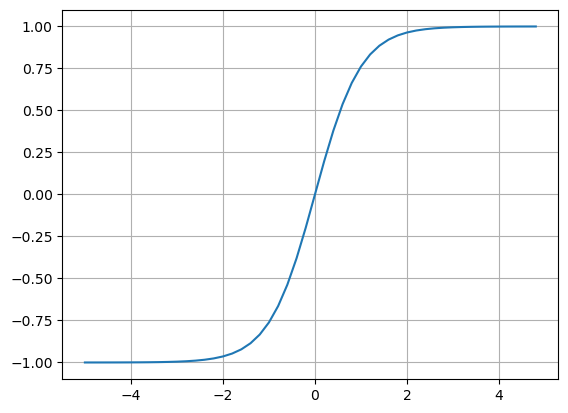

In [147]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [148]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [149]:
o.grad = 1.0

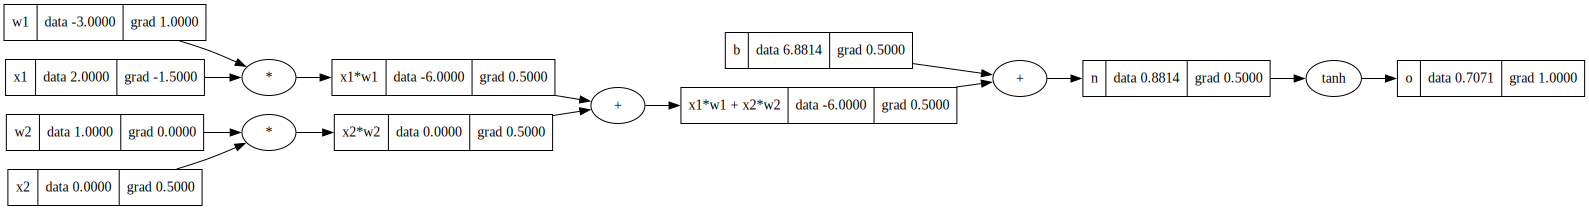

In [150]:
o.backward()
draw_dot(o)

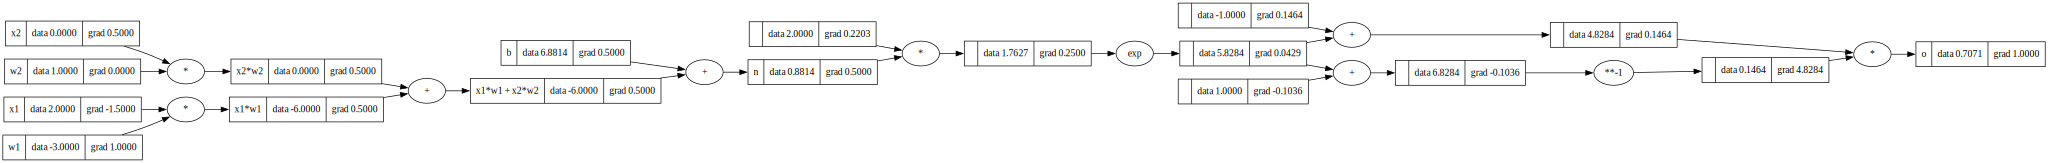

In [151]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

Pytorch

### PyTorch as a gradient sanity-check

This section rebuilds the *exact same* single-neuron computation (`x1*w1 + x2*w2 + b`, then `tanh`) using `torch.Tensor` with `requires_grad=True`, and compares its gradients against the hand-rolled `Value.backward()` above. If the two implementations agree, that's strong evidence `Value`'s autograd is correct.

**API mapping (micrograd -> PyTorch):**

| micrograd | PyTorch |
|---|---|
| `Value(data)` | `torch.Tensor([data])` |
| (always tracks grad) | `.requires_grad = True` |
| `out.backward()` | `o.backward()` |
| `v.data` | `t.item()` / `t.data` |
| `v.grad` (a `float`) | `t.grad` (a tensor, hence `.item()`) |
| `_prev` + `_backward` (your DAG + closures) | PyTorch's internal autograd graph (`grad_fn`) |

**Why `.double()`:** PyTorch tensors default to `float32`, but Python floats (and thus `Value.data`) are `float64`. Casting with `.double()` puts both implementations in the same precision so the compared gradients match closely rather than differing in the last few digits due to rounding.

**Note on shape:** each tensor here is a single-element 1D tensor used as a scalar - exactly like one `Value`. Normal PyTorch code operates on *batched* multi-dimensional tensors instead, but the underlying autograd mechanics (accumulate into `.grad`, build a DAG of ops, run a topological backward pass) are identical to what `Value.backward()` does.

In [152]:
import torch

In [153]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


### From `Value` to a tiny `nn.Module`

`Neuron` / `Layer` / `MLP` are a miniature version of `torch.nn.Module`, built entirely out of `Value`s:

| micrograd | PyTorch equivalent |
|---|---|
| `Neuron` (`sum(wi*xi) + b`, then `.tanh()`) | `nn.Linear(nin, 1)` followed by `torch.tanh` |
| `Layer` (a list of `Neuron`s) | `nn.Linear(nin, nout)` |
| `MLP` (a list of `Layer`s) | `nn.Sequential(...)` |
| `.parameters()` | `nn.Module.parameters()` |

**The training loop (below) is SGD, written by hand:**

```python
for p in n.parameters():
    p.grad = 0.0          # == optimizer.zero_grad()
loss.backward()           # == loss.backward()
for p in n.parameters():
    p.data += -0.1 * p.grad   # == optimizer.step(), SGD with lr=0.1
```

The `p.grad = 0.0` reset before each `backward()` is exactly the reason the earlier note about `+=` accumulation matters - without zeroing, gradients from previous steps would keep piling up.

**Init note:** `Neuron.__init__` initializes weights and bias with `random.uniform(-1, 1)`. PyTorch's `nn.Linear` uses a different default (Kaiming-uniform based on `fan_in`) - not wrong here, just a difference worth knowing if you ever compare convergence behavior between the two.

In [154]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

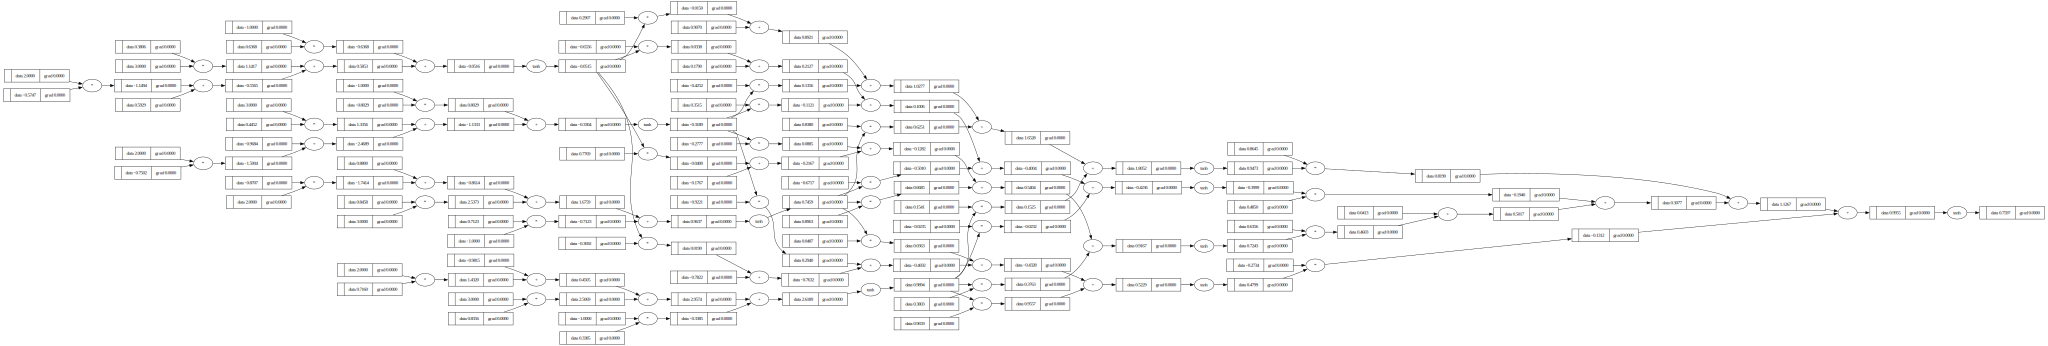

In [173]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)
draw_dot(n(x))

In [156]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [157]:
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)

0 9.02817649297388
1 2.290337537270817
2 2.3846546473113506
3 0.5316280728537224
4 0.02903175678367928
5 0.026660383419047314
6 0.024658515644639976
7 0.02294321095473795
8 0.021455292028820565
9 0.020151232840564137
10 0.018998204065770838
11 0.017970915835248034
12 0.017049532567107104
13 0.016218253343537624
14 0.01546431981701149
15 0.014777306981601856
16 0.014148605979067839
17 0.013571040263090379
18 0.013038576251526122
19 0.012546102135391797


In [158]:
ypred

[Value(data=0.9474212209398714),
 Value(data=-0.9584163952839682),
 Value(data=-0.9341885962121522),
 Value(data=0.9389980567667583)]